## Import libraries, as usual...

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

## Load dataset...

In [2]:
data = pd.read_csv("data/housing_clean.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range,total_bedrooms_smooth
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,129.0,"(435334.067, 467667.533]",129.0,226.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1106.0,"(338333.667, 370667.133]",1106.0,1273.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,190.0,"(338333.667, 370667.133]",190.0,325.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,235.0,"(338333.667, 370667.133]",235.0,292.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,280.0,"(338333.667, 370667.133]",280.0,352.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,374.0,"(47332.467, 79665.933]",374.0,358.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,150.0,"(47332.467, 79665.933]",150.0,195.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,485.0,"(79665.933, 111999.4]",485.0,457.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,409.0,"(79665.933, 111999.4]",409.0,391.0


## Select features for Scaling
##### More information regarding SelectKBest:
  * ##### https://scikit-learn.org/stable/modules/feature_selection.html
  * ##### https://medium.com/@Kavya2099/optimizing-performance-selectkbest-for-efficient-feature-selection-in-machine-learning-3b635905ed48#1cb1

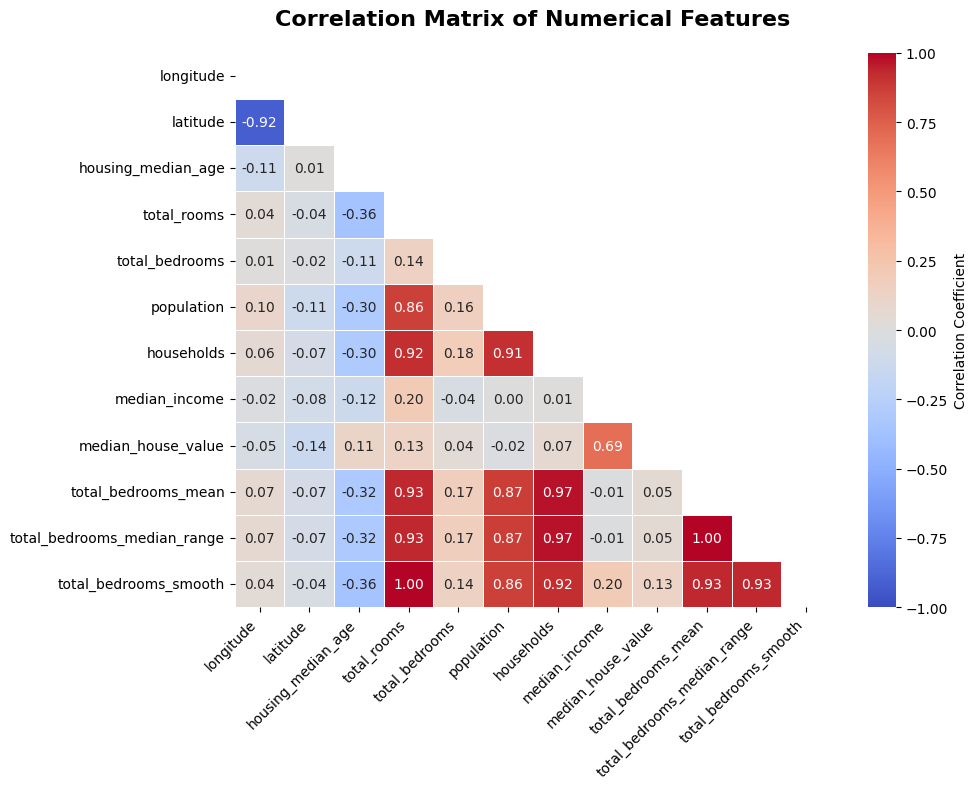

In [3]:
corr = data.drop(["ocean_proximity", "median_house_value_range"], axis=1).corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,  # Ensure that color scaling is consistent
    cbar_kws={"label": "Correlation Coefficient"},
    annot_kws={"size": 10},  # Adjust annotation size
    mask=mask,  # Apply the mask to hide the upper triangle
)

ax.set_title(
    "Correlation Matrix of Numerical Features", fontsize=16, fontweight="bold", pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 🧠 Feature Selection with `SelectKBest`

### ✅ What is `SelectKBest`?

`SelectKBest` is a method that **allows you to choose the "best" features** from your dataset.

How it works:
1. You give it your **features (X)** and **target (y)**.
2. It scores each feature **based on a statistical test**.
3. It keeps the **top `k` highest-scoring features**.

---

### 🧪 How does it score features? (The `score_func`)

The scoring method depends on the **type of your target variable (`y`)**:

---

#### 🔹 `f_classif` → For **classification problems**  
- Uses the **ANOVA F-test** to compare the means of different groups (classes).  
- Higher score = Feature is more **related to class labels**.

📘 Example: Predicting whether a person has diabetes (yes/no)  
📈 Input: Age, BMI, Glucose  
📊 This test will rank which features differ **significantly** between the classes.

---

#### 🔹 `f_regression` → For **regression problems**  
- Computes **correlation between each feature and the target**.
- Based on **linear regression's F-statistic**.

📘 Example: Predicting house prices  
📈 Input: Size, Number of rooms, Distance from city  
📊 This test ranks features that are **most linearly related** to the target.

---

#### 🔹 `chi2` → For **classification with non-negative features only**  
- Measures dependence using the **Chi-Squared test**.
- Works best when features are **frequencies or counts** (like in text data or image pixels).

📘 Example: Classifying emails as spam or not based on word counts  
📊 Chi-squared finds words that are **strongly associated** with either class.

---

#### 🔹 `mutual_info_classif` & `mutual_info_regression` → Non-linear dependencies  
- Measures **how much information** a feature gives us about the target.
- Can detect **non-linear relationships** that `f_classif` and `f_regression` miss.

📘 Example: Detecting complex relationships like XOR or curved trends  
📊 Based on **information theory** — higher score means more shared information.

### 🛠️ Example Usage


In [4]:
X = data.drop(columns=["total_bedrooms", "median_house_value_range", "ocean_proximity"])
y = data["ocean_proximity"]

skb = SelectKBest(mutual_info_classif, k="all").fit(X, y)

In [5]:
kbest = (
    pd.DataFrame(
        {
            "feature": skb.get_feature_names_out(),
            "score": skb.scores_,
        }
    )
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

In [6]:
kbest

,feature,score
0,longitude,0.688382
1,latitude,0.614339
2,median_house_value,0.211583
3,housing_median_age,0.055993
4,median_income,0.036209
5,households,0.013271
6,population,0.010351
7,total_bedrooms_mean,0.009171
8,total_bedrooms_smooth,0.007142
9,total_bedrooms_median_range,0.005746


In [7]:
# ALTERNATIVE ? pandas nlargest (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html)
# feats = kbest.nlargest(6, "score")["feature"].tolist()

feats = [
    "longitude",
    "latitude",
    "median_house_value",
    "housing_median_age",
    "median_income",
    "households",
]
targets = ["ocean_proximity", "median_house_value_range"]

X, y = data[feats].copy(), data[targets[0]].copy()

In [8]:
X

,longitude,latitude,median_house_value,housing_median_age,median_income,households
0,-122.23,37.88,452600.0,41.0,8.3252,126.0
1,-122.22,37.86,358500.0,21.0,8.3014,1138.0
2,-122.24,37.85,352100.0,52.0,7.2574,177.0
3,-122.25,37.85,341300.0,52.0,5.6431,219.0
4,-122.25,37.85,342200.0,52.0,3.8462,259.0
...,...,...,...,...,...,...
20635,-121.09,39.48,78100.0,25.0,1.5603,330.0
20636,-121.21,39.49,77100.0,18.0,2.5568,114.0
20637,-121.22,39.43,92300.0,17.0,1.7000,433.0
20638,-121.32,39.43,84700.0,18.0,1.8672,349.0


In [9]:
y

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

## Split to train/test sets...

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

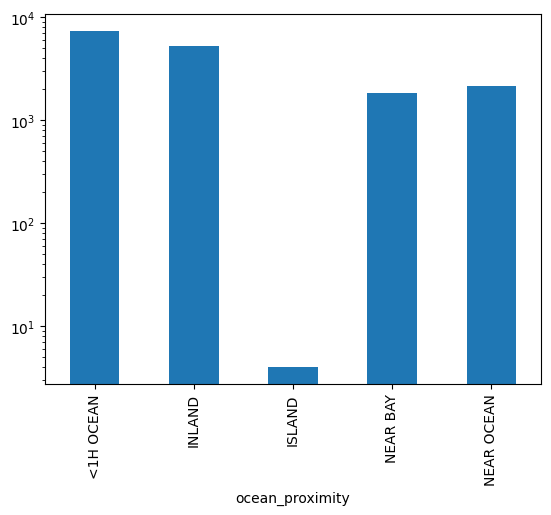

In [11]:
ax_train = y_train.value_counts(sort=False).sort_index().plot.bar()
ax_train.set_yscale("log")

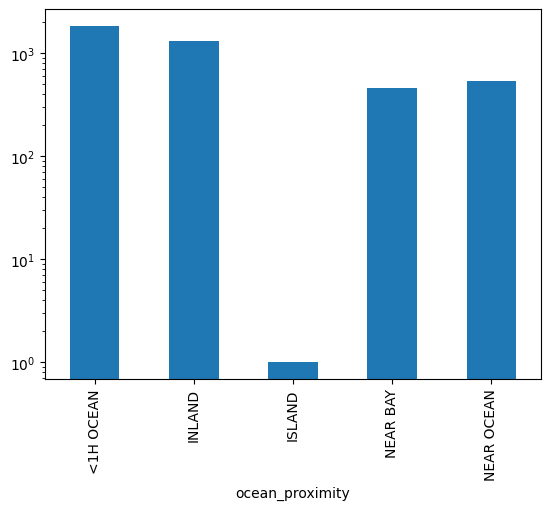

In [12]:
ax_test = y_test.value_counts(sort=False).sort_index().plot.bar()
ax_test.set_yscale("log")

## Normalize train/test sets...

In [13]:
# MinMaxScaler
# scaler = MinMaxScaler(feature_range=(0, 1), clip=True)


scaler = StandardScaler()
enc = LabelEncoder()

# SOS: NEVER CALL fit_transform ON test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_enc = enc.fit_transform(y.to_numpy().ravel()).reshape(-1, 1)

In [14]:
X_train_scaled

array([[-1.67089471,  1.34550396, -0.52717182,  0.66952453, -0.12694769,
        -0.07102314],
       [ 0.68712958, -0.70595793, -0.31780131,  1.22634079,  0.08913635,
        -0.57068348],
       [-0.41694535,  1.11547734, -0.82168054, -0.92137906, -0.64668443,
        -0.38331085],
       ...,
       [-1.53101191,  1.5567529 , -1.08925778, -0.84183388, -1.45787473,
         0.89446638],
       [ 0.68712958, -0.72943003, -0.32648888,  1.06725043, -0.26447982,
        -0.39892524],
       [ 0.89695378, -0.72943003, -0.72264221,  0.58997935, -0.53439923,
         0.33234849]])

In [15]:
y_enc

array([[3],
       [3],
       [3],
       ...,
       [1],
       [1],
       [1]])

## Cluster dataset using K-Means...

In [16]:
kmeans = KMeans(n_clusters=y.nunique(), random_state=42)
kmeans.fit(X=X_train_scaled)

KMeans(n_clusters=5, random_state=42)

In [17]:
kmeans.predict(X_test_scaled)

array([0, 1, 3, ..., 0, 2, 1], dtype=int32)

In [18]:
y_test.shape, kmeans.predict(X_test_scaled).shape

((4128,), (4128,))

### 🧪 Rand Index — `adjusted_rand_score(y_true, y_pred)`

The **Adjusted Rand Index (ARI)** measures the similarity between the **true labels** and the **cluster assignments** predicted by a clustering algorithm.

#### 🔍 What does it do?
It evaluates **how similar** two groupings are, while correcting for **chance**. Specifically:
- It compares all possible **pairs of points** and checks:
  - Are they in the **same cluster** in both `y_true` and `y_pred`?
  - Are they in **different clusters** in both?

#### 📐 Formula Highlights:
ARI adjusts the raw Rand Index by accounting for the **expected similarity** of random labelings.

#### 📊 Value range:
| ARI Score | Interpretation                      |
|-----------|-------------------------------------|
| 1.0       | Perfect clustering match            |
| 0.0       | Random labeling                     |
| < 0       | Worse than random                   |

> ✅ **Use ARI when you have ground-truth labels** and want to evaluate how well your clustering matches them — **label permutations don’t matter!**

---

### 🧪 Calinski-Harabasz Score — `calinski_harabasz_score(X, labels)`

The **Calinski-Harabasz Index (CHI)** evaluates **cluster validity** based on how well-separated and compact the clusters are.

#### 🔍 What does it do?
It computes the ratio of:
- **Between-cluster dispersion** (how far apart cluster centers are)
- **Within-cluster dispersion** (how tightly packed each cluster is)

> In other words, it rewards:
> - 👨‍👩‍👧‍👦 Clusters that are dense
> - 🌍 Clusters that are far apart

#### 📐 Formula Highlights:

$\text{CHI} = \frac{\text{Between-cluster variance}}{\text{Within-cluster variance}} \times \frac{(N - k)}{(k - 1)}$
- `N`: Number of samples
- `k`: Number of clusters

#### 📊 Value range:
- **Higher is better**!
- No theoretical upper bound — depends on dataset characteristics.

> ✅ **Use CHI when you do not have ground-truth labels** and still want to assess how meaningful your clusters are based purely on geometry.

---

### 📌 Summary Table

| Metric                    | Supervision Needed | Measures                         | Range       | Best |
|--------------------------|--------------------|----------------------------------|-------------|------|
| Adjusted Rand Index (ARI)| ✅ Yes             | Label agreement (adjusted)       | -1 to 1     | 1    |
| Calinski-Harabasz Index  | ❌ No              | Cluster separation & compactness | 0 to ∞      | ↑    |



In [19]:
# Get encoded ground truth
y_true = enc.transform(y_test.to_numpy().reshape(-1, 1)).flatten()

# Get predicted clusters
y_pred = kmeans.predict(X_test_scaled)

# Rand index (Adjusted Rand Score)
rand_idx = adjusted_rand_score(y_true, y_pred)

# Calinski-Harabasz Index
calinski_score = calinski_harabasz_score(X_test, y_pred)

print(f"Adjusted Rand Index: {rand_idx:.4f}")
print(f"Calinski-Harabasz Score: {calinski_score:.2f}")

Adjusted Rand Index: 0.1635
Calinski-Harabasz Score: 1761.84


/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


## Visualize Results using PCA...

In [20]:
pca2d = PCA(n_components=2)
X_train_scaled_2d = pca2d.fit_transform(X_train_scaled)
X_test_scaled_2d = pca2d.transform(X_test_scaled)

In [21]:
pca2d.explained_variance_ratio_, np.sum(pca2d.explained_variance_ratio_)

(array([0.32902566, 0.27968863]), np.float64(0.6087142927779626))

In [22]:
enc.transform(y_test.values.ravel())

array([3, 1, 0, ..., 0, 0, 1])

/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


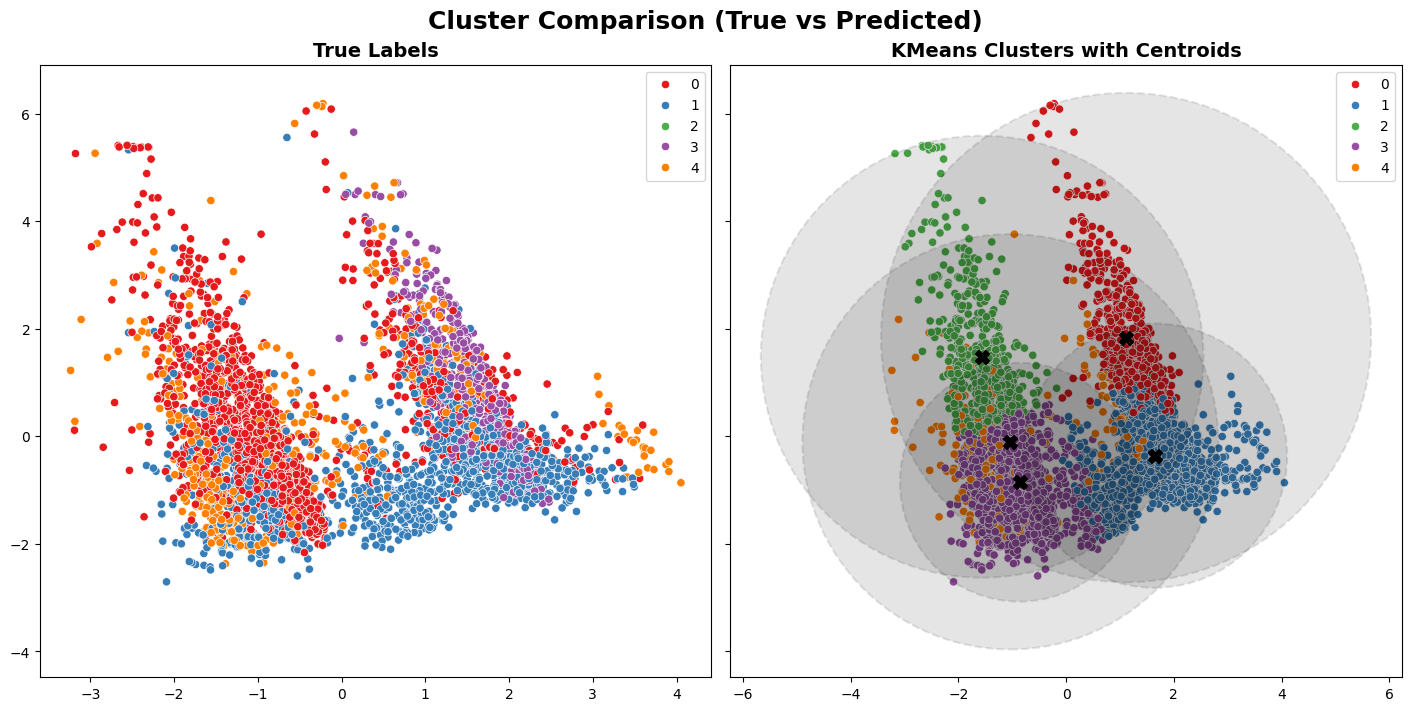

In [23]:
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 2, figsize=(14, 7), layout="constrained", sharey=True)

# True Labels Plot
sns.scatterplot(
    ax=axes[0],
    x=X_test_scaled_2d[:, 0],
    y=X_test_scaled_2d[:, 1],
    hue=enc.transform(y_test.values.reshape(-1, 1)).ravel(),
    palette="Set1",
    legend=True,
)
axes[0].set_title("True Labels", fontsize=14, fontweight="bold")

# KMeans Predictions Plot
labels = kmeans.predict(X_test_scaled)
sns.scatterplot(
    ax=axes[1],
    x=X_test_scaled_2d[:, 0],
    y=X_test_scaled_2d[:, 1],
    hue=labels,
    palette="Set1",
    legend=True,
)

# Get centroids projected into 2D (same transformation as X_test_scaled_2d)
centroids_2d = pca2d.transform(kmeans.cluster_centers_)

# Plot centroids and radius
for i, (x, y) in enumerate(centroids_2d):
    # Plot centroid
    axes[1].scatter(
        x, y, c="black", marker="X", s=100, label=f"Centroid {i}" if i == 0 else None
    )

    # Estimate radius as max distance to centroid in 2D
    cluster_points = X_test_scaled_2d[labels == i]
    radius = np.linalg.norm(cluster_points - [x, y], axis=1).max()

    circle = Circle((x, y), radius, color="black", alpha=0.1, linestyle="--", linewidth=1.5)
    axes[1].add_patch(circle)

axes[1].set_title("KMeans Clusters with Centroids", fontsize=14, fontweight="bold")
plt.suptitle("Cluster Comparison (True vs Predicted)", fontsize=18, fontweight="bold")
plt.show()

## How to find the optimal **k**?

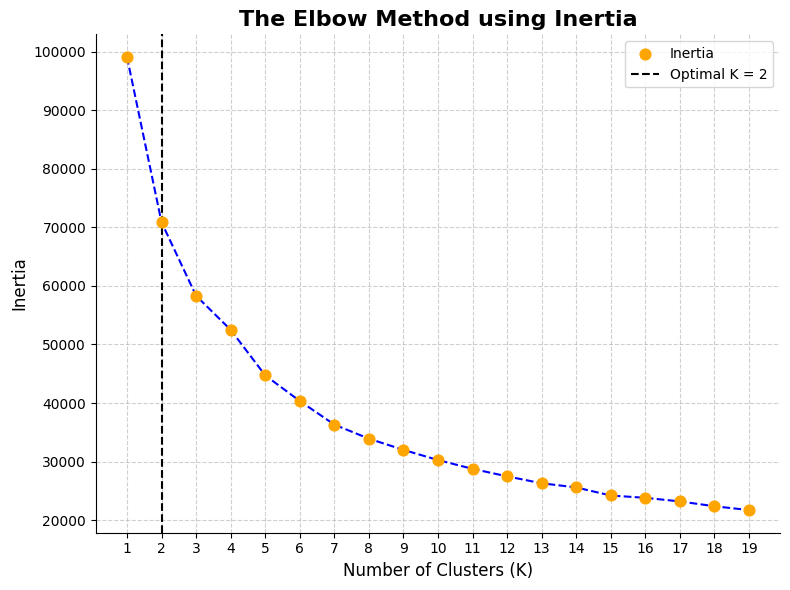

In [24]:
inertias = []
K = range(1, 20)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(X_train_scaled)
    inertias.append(kmeanModel.inertia_)

# Compute the differences in inertia values to find the slope
diff_inertias = np.diff(inertias)
slope_changes = np.diff(diff_inertias)

# Find the index of the highest slope change
optimal_k = np.argmax(slope_changes) + 2  # +2 because the diff reduces by 2 indices

# Plot
plt.figure(figsize=(8, 6))
plt.plot(K, inertias, color="blue", linestyle="--", linewidth=1.5)
plt.scatter(K, inertias, color="orange", s=60, zorder=5, label="Inertia")
plt.axvline(
    x=optimal_k,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Optimal K = {optimal_k}",
)

plt.title("The Elbow Method using Inertia", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(K)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

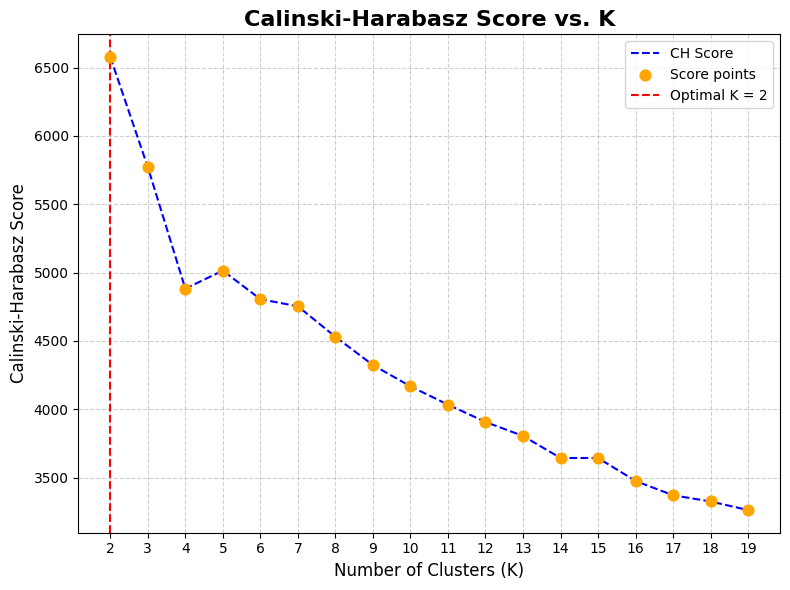

In [25]:
ch_scores = []
K = range(2, 20)

for k in K:
    # Building and fitting the model
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X_train_scaled)
    ch_scores.append(
        calinski_harabasz_score(X_train_scaled, kmeanModel.predict(X_train_scaled))
    )

# Find the optimal K based on the maximum Calinski-Harabasz score
optimal_k = K[np.argmax(ch_scores)]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(K, ch_scores, color="blue", linestyle="--", linewidth=1.5, label="CH Score")
plt.scatter(K, ch_scores, color="orange", s=60, zorder=5, label="Score points")
plt.axvline(
    x=optimal_k,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Optimal K = {optimal_k}",
)

plt.title("Calinski-Harabasz Score vs. K", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Calinski-Harabasz Score", fontsize=12)
plt.xticks(K)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

##### Higher value of CH index means the clusters are dense and well separated, although there is no “acceptable” cut-off value. We need to choose that solution which gives a peak or at least an abrupt elbow on the line plot of CH indices. On the other hand, if the line is smooth (horizontal or ascending or descending) then there is no such reason to prefer one solution over others. [source: Geeks-for-Geeks](https://www.geeksforgeeks.org/calinski-harabasz-index-cluster-validity-indices-set-3/)

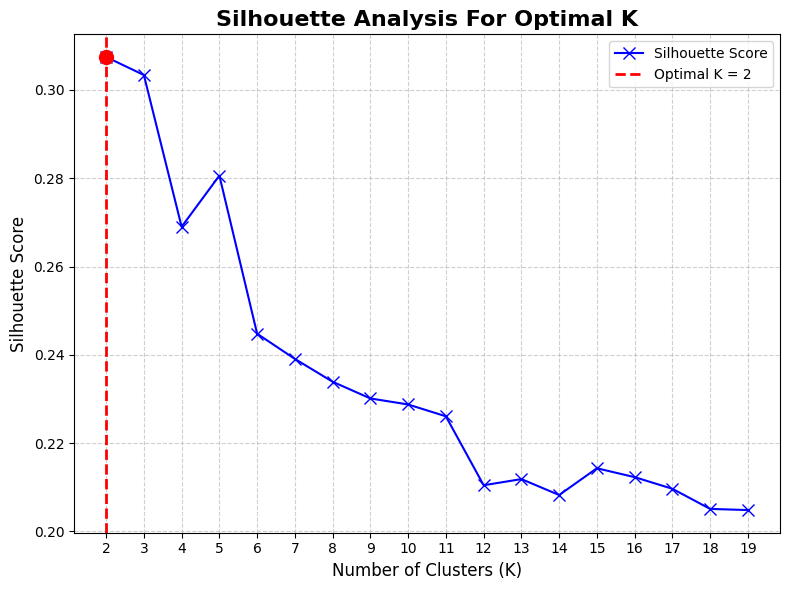

In [26]:
silhouette_scores = []
K = range(2, 20)

for k in K:
    # Initialise kmeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)

    # Silhouette score
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Find the optimal K based on the maximum silhouette score
optimal_k = K[np.argmax(silhouette_scores)]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(K, silhouette_scores, "bx-", label="Silhouette Score", markersize=8)
plt.axvline(
    x=optimal_k, color="red", linestyle="--", linewidth=2, label=f"Optimal K = {optimal_k}"
)
plt.scatter(
    optimal_k, silhouette_scores[np.argmax(silhouette_scores)], color="red", s=100, zorder=5
)

plt.title("Silhouette Analysis For Optimal K", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(K)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Running k-Means for the best **k**

In [27]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X=X_test_scaled)

KMeans(n_clusters=2, random_state=42)

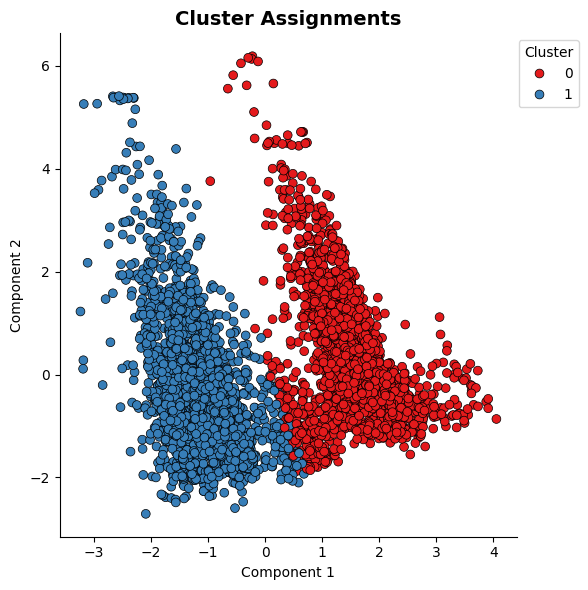

In [28]:
_, ax = plt.subplots(1, 1, figsize=(6, 6))

# Note: seaborn expects "hue" for coloring categories, not "c"
sns.scatterplot(
    x=X_test_scaled_2d[:, 0],
    y=X_test_scaled_2d[:, 1],
    hue=kmeans.predict(X_test_scaled),
    palette="Set1",
    ax=ax,
    s=40,  # optional: adjust marker size
    edgecolor="k",  # optional: outline for better visibility
)

ax.set_title("Cluster Assignments", fontsize=14, fontweight="bold")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
sns.despine(ax=ax)
plt.legend(title="Cluster", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

### 🧠 Why Clustering Algorithms May Detect a Different Number of Clusters than Reality

Obviously this is not the expected result. 

Clustering is **unsupervised**, meaning the algorithm has **no knowledge of the true labels** or how many clusters should exist (in our case 5). Here are the key reasons why the number of detected clusters might differ:

---

#### 1. **Algorithmic Assumptions**
- Each clustering algorithm makes specific assumptions:
  - **KMeans** assumes **spherical, equally sized clusters** and minimizes **intra-cluster variance**.
  - **DBSCAN** assumes **dense regions separated by sparse areas**.
  - **Gaussian Mixture Models (GMMs)** assume data is generated from a mixture of **Gaussian distributions**.
- If real data violates these assumptions, the algorithm might **overestimate or underestimate** the true number of clusters.

---

#### 2. **Parameter Sensitivity**
- Many algorithms are **sensitive to hyperparameters**:
  - `n_clusters` in KMeans
  - `eps` and `min_samples` in DBSCAN
  - `covariance_type` in GMM
- Incorrect settings lead to misidentification:
  - **Too low `eps`** in DBSCAN → many small clusters or lots of noise
  - **Too high `n_clusters`** in KMeans → forced over-segmentation

---

#### 3. **Noise and Outliers**
- **Noisy data or outliers** may distort cluster boundaries.
- Algorithms like DBSCAN handle noise explicitly, but others may **force outliers into clusters**, skewing results.

---

#### 4. **Cluster Density & Shape**
- Real-world data may have **uneven density**, **overlapping**, or **non-spherical** clusters.
- Algorithms designed for simple geometries (e.g., KMeans) may **split one real cluster** into many or **merge separate clusters**.

---

#### 5. **Scale and Feature Importance**
- If features are not properly scaled or weighted, **irrelevant features** can mislead the algorithm.
- E.g., one high-variance feature can dominate the distance metric and skew cluster formation.

---

#### 6. **Evaluation Without Ground Truth**
- In unsupervised learning, it's often unclear what the “correct” number of clusters is.
- Metrics like **Silhouette Score**, **Calinski-Harabasz**, or **Elbow Method** are used to estimate—but they don't guarantee alignment with real labels.

---

### 📌 In Summary:
> Clustering outcomes differ from reality due to assumptions, parameter sensitivity, data complexity, and lack of ground truth. Clustering is more about **finding meaningful structure**, not necessarily matching the real number of classes.



In [29]:
y_pred = kmeans.predict(X_test_scaled)

In [30]:
for label in np.unique(kmeans.labels_):
    print(f"Cluster {label}: {len(kmeans.labels_[kmeans.labels_ == label])} points")

Cluster 0: 1791 points
Cluster 1: 2337 points


In [31]:
adjusted_rand_score(y_test, kmeans.predict(X_test_scaled))

0.18917823597957778

## Clustering dataset with DBSCAN...

In [32]:
dbscan = DBSCAN(n_jobs=-1)
dbscan.fit(X_train_scaled, y=y_enc)

DBSCAN(n_jobs=-1)

In [33]:
np.unique(dbscan.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [34]:
dbscan.core_sample_indices_, dbscan.core_sample_indices_.shape

(array([    0,     1,     2, ..., 16507, 16510, 16511]), (12614,))

In [35]:
np.where(dbscan.labels_ == -1), np.where(dbscan.labels_ == -1)[0].shape

((array([    8,    14,    37, ..., 16502, 16508, 16509]),), (2295,))

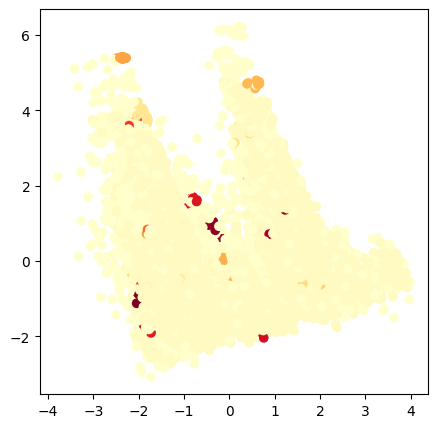

In [36]:
# DBSCAN does not have a predict method (why? - starting point: https://stackoverflow.com/a/69239363)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(X_train_scaled_2d[:, 0], X_train_scaled_2d[:, 1], c=dbscan.labels_, cmap="YlOrRd")

### Why DBSCAN Does Not Have a `predict()` Method

1. **No Predefined Cluster Centers**  
   - Unlike algorithms like KMeans that use centroids (e.g., mean of points) to predict cluster membership, DBSCAN uses **density-based clustering** and does not rely on fixed cluster centers.

2. **Clusters Based on Density**  
   - DBSCAN forms clusters dynamically by grouping **dense regions** and leaving **low-density regions** as noise. There is no concept of "cluster centroids" to assign new data points to.

3. **No Assumption of Cluster Shape**  
   - DBSCAN can detect clusters of **arbitrary shapes**. Since there's no fixed cluster boundary, it is not straightforward to classify new points into existing clusters.

4. **Cluster Labels Assigned During `fit()`**  
   - DBSCAN assigns cluster labels (or marks points as noise) during the `fit()` phase. New points cannot be directly assigned to clusters using a `predict()` method.

5. **Alternative for New Data Points**  
   - To assign new data points, you can:
     - Refit DBSCAN with the new data.
     - Manually calculate density to check if the point belongs to an existing cluster or is noise.

#### Conclusion:
DBSCAN doesn't have a `predict()` method because it doesn't use fixed cluster centers and assigns points based on **density**. To classify new points, refit the model or implement custom methods to evaluate density.


In [37]:
# Finding the Optimal value of EPS
# Sources:
# [1] https://www.kaggle.com/code/tanmaymane18/nearestneighbors-to-find-optimal-eps-in-dbscan
# [2] https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/

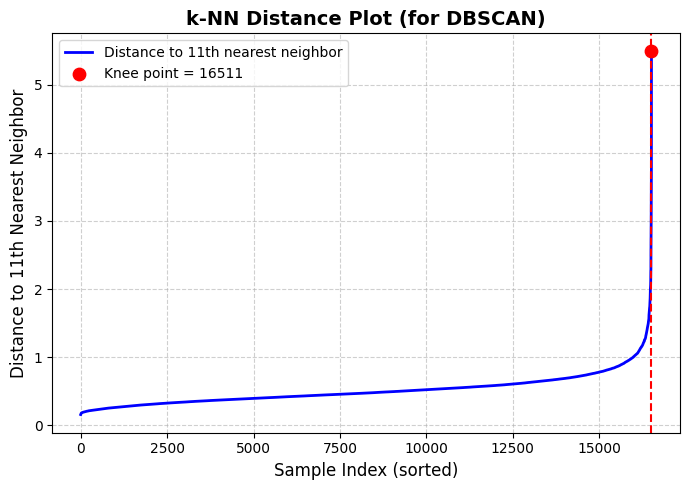

In [38]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Fit NearestNeighbors model and calculate distances
nearest_neighbors = NearestNeighbors(n_neighbors=11)
neighbors = nearest_neighbors.fit(X_train_scaled)

distances, indices = neighbors.kneighbors(X_train_scaled)
distances = np.sort(distances[:, 10], axis=0)

# Find the knee point (approximate where the slope increases sharply)
knee_point = np.argmax(np.diff(distances)) + 1  # Add 1 because diff reduces length by 1

# Plot
fig = plt.figure(figsize=(7, 5))
plt.plot(distances, color="b", label="Distance to 11th nearest neighbor", linewidth=2)
plt.scatter(
    knee_point,
    distances[knee_point],
    color="red",
    s=80,
    label=f"Knee point = {knee_point}",
    zorder=5,
)
plt.axvline(knee_point, color="red", linestyle="--", linewidth=1.5)

plt.title("k-NN Distance Plot (for DBSCAN)", fontsize=14, fontweight="bold")
plt.xlabel("Sample Index (sorted)", fontsize=12)
plt.ylabel("Distance to 11th Nearest Neighbor", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

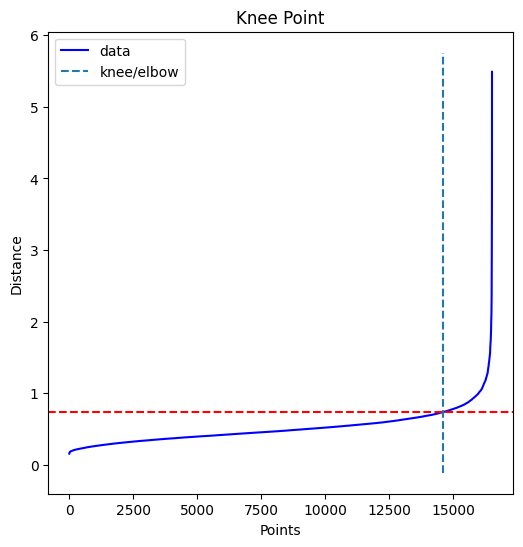

In [39]:
from kneed import KneeLocator

i = np.arange(len(distances))
knee = KneeLocator(
    i, distances, S=1, curve="convex", direction="increasing", interp_method="polynomial"
)

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
plt.axhline(y=distances[knee.knee], color="red", linestyle="--", linewidth=1.5)
plt.show()

### 🧠 Why are the results different?

np.argmax(np.diff(distances)) just looks at where the jump between consecutive distances is largest.\
KneeLocator fits a curve (e.g., polynomial) and computes where the curve bends most, even if there's no sudden change between adjacent points.

So:
- If the data has a sharp elbow, both methods often agree.
- If the data is smooth or noisy, KneeLocator will usually give a more stable and meaningful eps.

In [48]:
dbscan = DBSCAN(eps=distances[knee.knee], n_jobs=-1)
dbscan.fit(X_train_scaled)

DBSCAN(eps=np.float64(0.7370215046756916), n_jobs=-1)

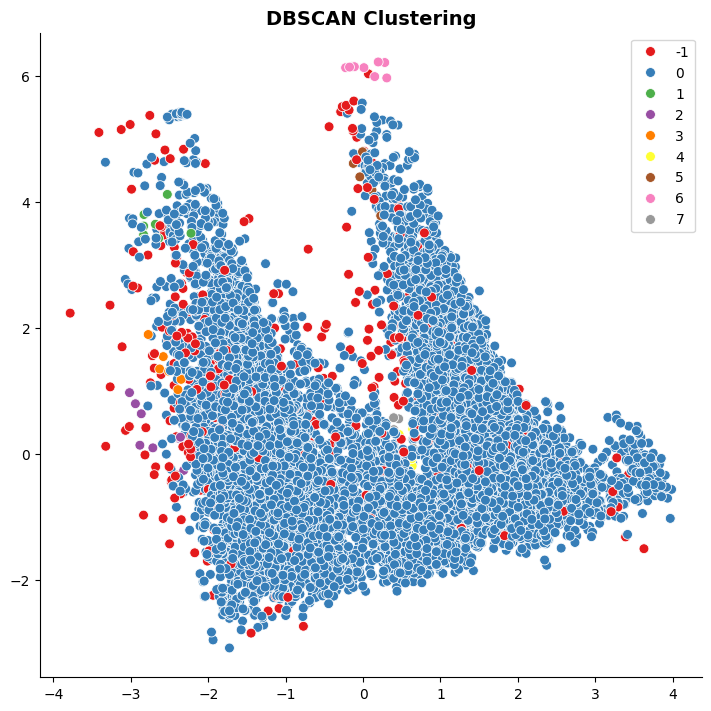

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), layout="constrained")

sns.scatterplot(
    x=X_train_scaled_2d[:, 0],
    y=X_train_scaled_2d[:, 1],
    hue=dbscan.labels_,
    palette="Set1",
    ax=ax,
    legend="full",
    s=50,
)
ax.set_title("DBSCAN Clustering", fontsize=14, fontweight="bold")
sns.despine()
plt.show()

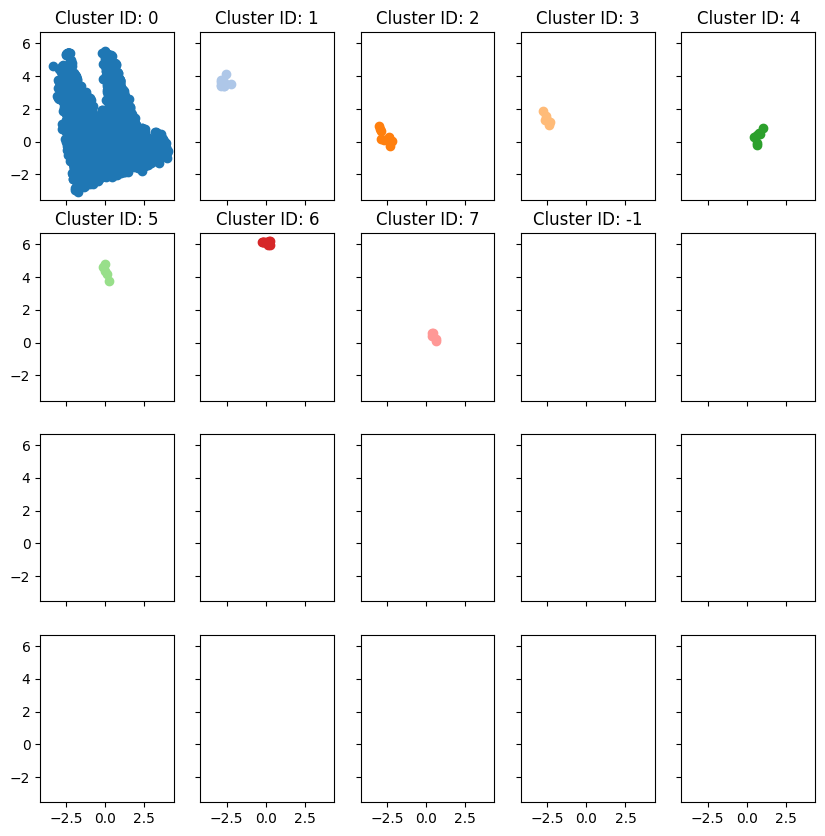

In [50]:
fig, ax = plt.subplots(4, 5, figsize=(10, 10), sharex=True, sharey=True)
ax_flat = ax.flatten()

for i, cluster_id in enumerate(set(dbscan.labels_)):
    mask = dbscan.labels_ == cluster_id
    ax_flat[i].scatter(
        X_train_scaled_2d[mask, 0],
        X_train_scaled_2d[mask, 1],
        color=plt.cm.tab20(cluster_id) if cluster_id != -1 else "white",
    )
    ax_flat[i].set_title(f"Cluster ID: {cluster_id}")

plt.show()

In [43]:
y_train.shape, dbscan.labels_.shape

((16512,), (16512,))

## Extra: Analyzing Clusters...
### ...using association rules (apriori algorithm; [tutorial](https://medium.com/analytics-vidhya/association-analysis-in-python-2b955d0180c))

In [44]:
# !pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

In [45]:
import geopandas as gpd

dbscan_cluster = gpd.GeoDataFrame(
    gdf := X_train[dbscan.labels_ == 1],
    geometry=gpd.points_from_xy(gdf.longitude, gdf.latitude),
    crs=4326,
)

In [46]:
for col in dbscan_cluster.columns[:-1]:
    dbscan_cluster.loc[:, f"{col}_bin"] = pd.cut(
        dbscan_cluster[col], bins=20, include_lowest=True
    )

ValueError: Cannot cut empty array

In [ ]:
freq_items = apriori(
    pd.get_dummies(dbscan_cluster).iloc[:, 7:].astype(bool),
    min_support=0.4,
    use_colnames=True,
    max_len=None,
    verbose=0,
)

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.8,
    support_only=False,
)

In [ ]:
rules